In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [3]:
MSCI_ETF_MAP = {
    # ── Developed Europe ──────────────────────────────────────────────
    "AUT": "EWO",   # Austria
    "BEL": "EWK",   # Belgium
    "DNK": "EDEN",  # Denmark
    "FIN": "EFNL",  # Finland
    "FRA": "EWQ",   # France
    "DEU": "EWG",   # Germany
    "IRL": "EIRL",  # Ireland
    "ITA": "EWI",   # Italy
    "NLD": "EWN",   # Netherlands
    "NOR": "ENOR",  # Norway
    "PRT": "PGAL",  # Portugal
    "ESP": "EWP",   # Spain
    "SWE": "EWD",   # Sweden
    "CHE": "EWL",   # Switzerland
    "GBR": "EWU",   # United Kingdom

    # ── Emerging Europe ───────────────────────────────────────────────
    "POL": "EPOL",  # Poland
    "RUS": "ERUS",  # Russia (delisted/suspended post-2022)
    "TUR": "TUR",   # Turkey
    "CZE": None,    # Czech Republic — no liquid single-country ETF
    "HUN": None,    # Hungary — no liquid single-country ETF
    "GRC": "GREK",  # Greece

    # ── Americas ──────────────────────────────────────────────────────
    "USA": "EUSA",  # United States (S&P 500 proxy; URTH for MSCI World)
    "CAN": "EWC",   # Canada
    "BRA": "EWZ",   # Brazil
    "MEX": "EWW",   # Mexico
    "CHL": "ECH",   # Chile
    "COL": "COLO",   # Colombia
    "PER": "EPU",   # Peru
    "ARG": "ARGT",   # Argentina

    # ── Asia Pacific ──────────────────────────────────────────────────
    "AUS": "EWA",   # Australia
    "NZL": "ENZL",  # New Zealand
    "JPN": "EWJ",   # Japan
    "KOR": "EWY",   # South Korea
    "TWN": "EWT",   # Taiwan
    "HKG": "EWH",   # Hong Kong
    "SGP": "EWS",   # Singapore
    "CHN": "MCHI",  # China
    "IND": "INDA",  # India
    "IDN": "EIDO",  # Indonesia
    "MYS": "EWM",   # Malaysia
    "THA": "THD",   # Thailand
    "PHL": "EPHE",  # Philippines
    "VNM": "VNM",   # Vietnam
    "PAK": "PAK",   # Pakistan

    # ── Middle East & Africa ──────────────────────────────────────────
    "ZAF": "EZA",   # South Africa
    "EGY": "EGPT",  # Egypt
    "NGA": "NGE",   # Nigeria
    "ISR": "EIS",   # Israel
    "ARE": "UAE",   # UAE
    "SAU": "KSA",   # Saudi Arabia
    "QAT": "QAT",   # Qatar
    "KWT": "KWT",  # Kuwait
}

In [4]:
valid_etfs = [etf for etf in MSCI_ETF_MAP.values() if etf is not None]
df = yf.download(valid_etfs, period="max", auto_adjust=True)["Close"]
df

[*********************100%***********************]  50 of 50 completed


Ticker,ARGT,COLO,ECH,EDEN,EFNL,EGPT,EIDO,EIRL,EIS,ENOR,...,KWT,MCHI,NGE,PAK,PGAL,QAT,THD,TUR,UAE,VNM
Date,,,,,,,,,,,,,,,,,,,,,
1996-03-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1996-03-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1996-03-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1996-03-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1996-03-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-11,89.769997,38.709999,40.639999,103.589996,49.240002,NaN,16.170,71.320000,120.809998,34.849998,...,36.904999,58.310001,NaN,NaN,NaN,18.799999,67.010002,39.290001,18.680000,17.410000
2026-03-12,86.669998,38.150002,39.279999,102.099998,49.130001,NaN,15.860,69.029999,117.699997,34.860001,...,36.654999,57.680000,NaN,NaN,NaN,18.700001,65.900002,39.340000,17.889999,16.750000
2026-03-13,85.510002,37.410000,38.849998,100.580002,48.439999,NaN,15.520,68.150002,117.919998,34.459999,...,36.351002,57.779999,NaN,NaN,NaN,18.740000,65.300003,38.660000,17.760000,16.709999


In [5]:
# Reindex to yearly frequency, taking the last available price of each year
df_yearly = df.resample("Y").last()
df_yearly.index = df_yearly.index.year  # Convert to year format
df_yearly

/var/folders/_x/74827dzs033cwdj2j4gch59r0000gn/T/ipykernel_5146/2140910896.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_yearly = df.resample("Y").last()


Ticker,ARGT,COLO,ECH,EDEN,EFNL,EGPT,EIDO,EIRL,EIS,ENOR,...,KWT,MCHI,NGE,PAK,PGAL,QAT,THD,TUR,UAE,VNM
Date,,,,,,,,,,,,,,,,,,,,,
1996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


MSCI return correlations are used only for calibration — they identify ϕ0\phi_0
ϕ0​ and ρ\rho
ρ by matching the observed integration pattern across the countries where data exists. You do not need global MSCI coverage for this, just enough country pairs to pin down the parameters. Your core EU countries plus ROW (ACWX) is sufficient.

Once calibrated, the model itself generates capital flows for all countries including those without MSCI data. The gravity equation produces Ωi,j\Omega_{i,j}
Ωi,j​ for any pair as long as you have the covariates — distance, language, legal index — which are available globally from CEPII and ICRG. So a country without an MSCI ETF still gets a well-defined σ~\tilde{\sigma}
σ~ and participates fully in the equilibrium.

This is actually a strength of structural modelling over pure empirics — you use clean data where it exists to calibrate the mechanism, then let the mechanism extrapolate to data-sparse regions. You should frame it this way in the thesis: the model is calibrated on observable equity market integration, then used to simulate counterfactual capital flows for the full country set including those without deep equity markets.
The only caveat is that for countries without MSCI data you cannot validate the model's predictions out-of-sample in the same way. Flag this honestly — predicted flows for Czech Republic or Hungary are model-implied, not directly comparable to an observed market benchmark.

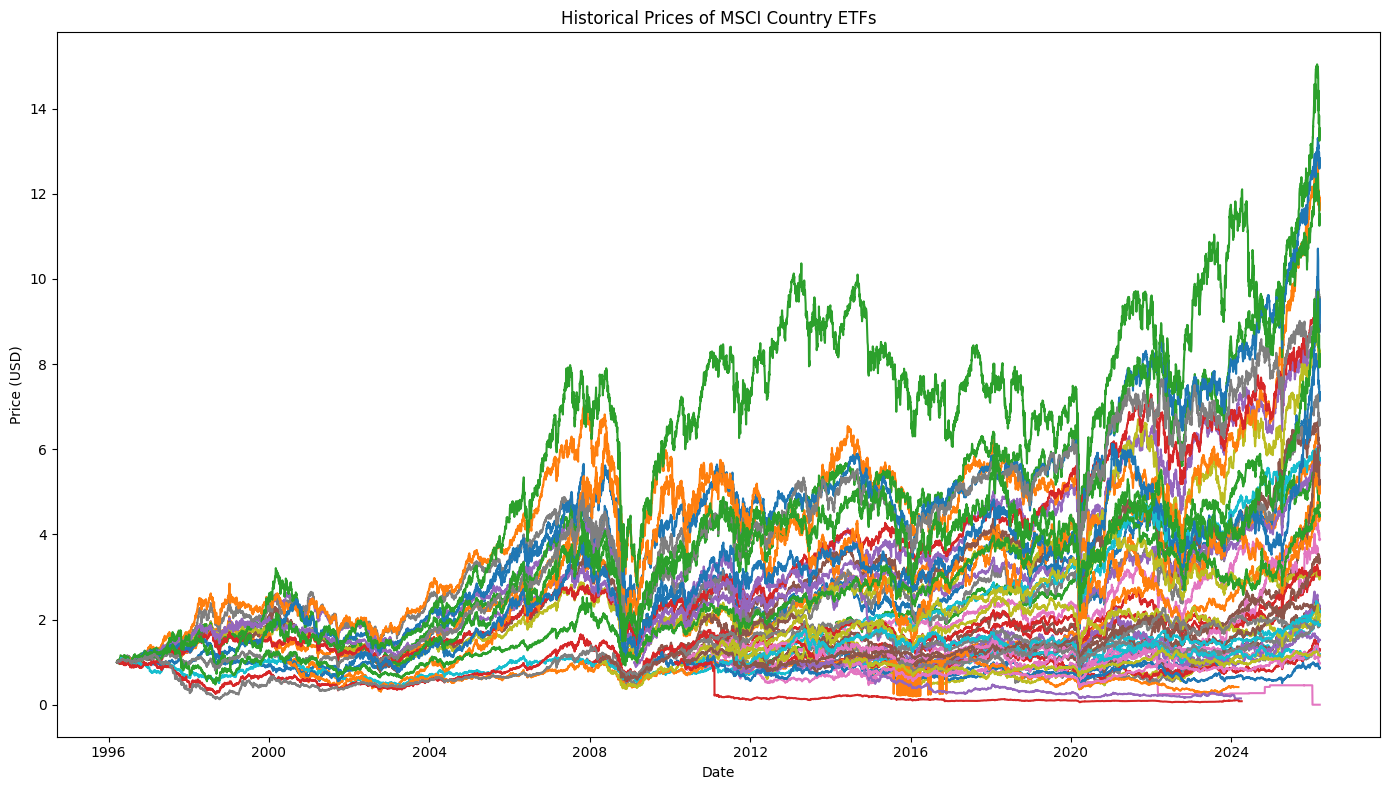

In [6]:
# plot them all
plt.figure(figsize=(14, 8))
for etf in valid_etfs:
    plt.plot(df[etf] / df[etf].bfill().iloc[0], label=etf)
plt.title("Historical Prices of MSCI Country ETFs")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

In [7]:
# Melt the dataframe from wide to long format for easier analysis
df_yearly_long = df_yearly.reset_index().melt(id_vars="Date", var_name="ETF", value_name="Price")
# Add the iso3 code from reverse mapping
etf_to_iso = {v: k for k, v in MSCI_ETF_MAP.items() if v is not None}
df_yearly_long["iso3"] = df_yearly_long["ETF"].map(etf_to_iso)
df_yearly_long

,Date,ETF,Price,iso3
0,1996,ARGT,NaN,ARG
1,1997,ARGT,NaN,ARG
2,1998,ARGT,NaN,ARG
3,1999,ARGT,NaN,ARG
4,2000,ARGT,NaN,ARG
...,...,...,...,...
1545,2022,VNM,11.209996,VNM
1546,2023,VNM,12.893303,VNM
1547,2024,VNM,11.456278,VNM
1548,2025,VNM,19.080000,VNM


In [8]:
# Rename Date to year for clarity
df_yearly_long.rename(columns={"Date": "Year"}, inplace=True)

In [9]:
# Now save it
df_yearly_long.to_csv("../Clean/MSCI_Country_ETFs_Yearly.csv", index=False)

In [10]:
# import pycountry and see how well they matcht o the iso3 codes we have denoted
import pycountry

iso3_codes = set(df_yearly_long["iso3"].unique())
pycountry_iso3 = {country.alpha_3 for country in pycountry.countries}
missing_iso3 = iso3_codes - pycountry_iso3
print("ISO3 codes in our dataset not found in pycountry:", missing_iso3)    

ISO3 codes in our dataset not found in pycountry: set()


In [12]:
df_yearly_long.isna().sum() / len(df_yearly_long)

Year     0.000000
ETF      0.000000
Price    0.300645
iso3     0.000000
dtype: float64